# AI/ML Project - Smart School ECAM

This notebook is divided into two main parts:

1. Failure prediction: prediction of students' exam grades.
2. Automatic correction: OCR-based recognition of handwritten characters or digits.

# Part A - Failure Prediction

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
sns.set_theme(style="whitegrid")

## Chargement du dataset

#### Dataset Overview

In [3]:
df = pd.read_csv("../data/student_failure/train.csv")
df.head()

,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


#### Dataset Shape

In [4]:
df.shape

(630000, 15)

#### Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        630000 non-null  int64  
 1   age                       630000 non-null  int64  
 2   genre                     630000 non-null  str    
 3   diplôme                   630000 non-null  str    
 4   heures_etude              611100 non-null  float64
 5   assiduité_classe          630000 non-null  float64
 6   accès_internet            567000 non-null  str    
 7   heures_sommeil            630000 non-null  float64
 8   qualité_sommeil           630000 non-null  str    
 9   méthode_etude             585900 non-null  str    
 10  évaluation_établissement  630000 non-null  str    
 11  difficulté_examen         630000 non-null  str    
 12  score_examen              630000 non-null  float64
 13  heures_fête               630000 non-null  int64  
 14 

#### Column Names

In [6]:
df.columns

Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='str')

### Dataset Description

Le dataset contient environ 630 000 observations et 15 variables. Il s’agit d’un dataset relativement volumineux, ce qui est avantageux pour l’entraînement de modèles de Machine Learning, car cela permet d’avoir un grand nombre d’exemples et de limiter le risque d’overfitting.

La variable cible est `score_examen`, qui représente la note finale obtenue par l’étudiant. Étant donné que cette variable est continue et numérique, le problème est formulé comme un problème de régression.

Le dataset contient à la fois des variables numériques et catégorielles :
- Variables numériques : âge, heures d’étude, assiduité, heures de sommeil, etc.
- Variables catégorielles : genre, niveau d’étude, accès à internet, méthode d’étude, difficulté de l’examen, etc.

Une première analyse montre la présence de valeurs manquantes dans certaines colonnes, notamment `heures_etude`, `acces_internet` et `methode_etude`. Ces valeurs devront être traitées lors de la phase de preprocessing.

Enfin, la diversité des variables suggère que plusieurs facteurs peuvent influencer la performance des étudiants, ce qui rend ce problème particulièrement intéressant pour une analyse prédictive.

Cependant, certaines variables peuvent être déclaratives (par exemple les heures d’étude), ce qui peut introduire un biais ou des incohérences dans les données et affecter les prédictions du modèle.

## Exploratory Data Analysis (EDA)

### Distribution of the Target Variable

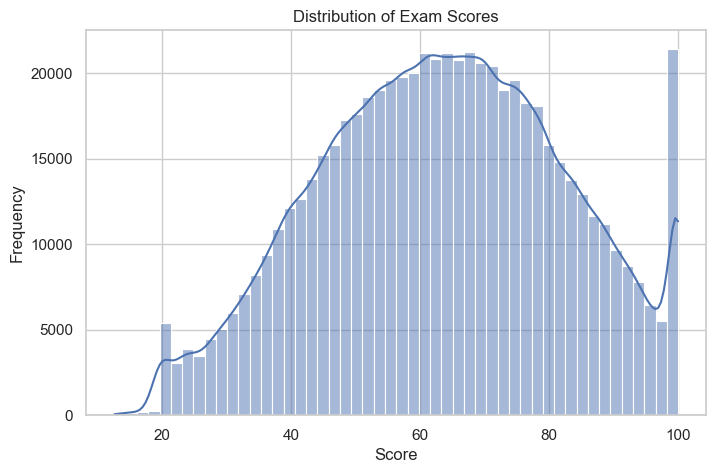

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["score_examen"], bins=50, kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

#### Analysis

La distribution de la variable cible `score_examen` montre une répartition globalement en forme de cloche, ce qui suggère une distribution proche d’une loi normale.

La majorité des étudiants obtiennent des scores autour de 60 à 70, ce qui indique un niveau moyen global.

On observe également une concentration de valeurs proches de 100, ce qui peut s’expliquer par un effet de plafond (score maximal atteint).

Cette distribution confirme que la variable cible est continue et adaptée à un problème de régression.

La présence d’un pic près de 100 pourrait indiquer soit des étudiants très performants, soit une limite dans le système de notation.

### Correlation Analysis

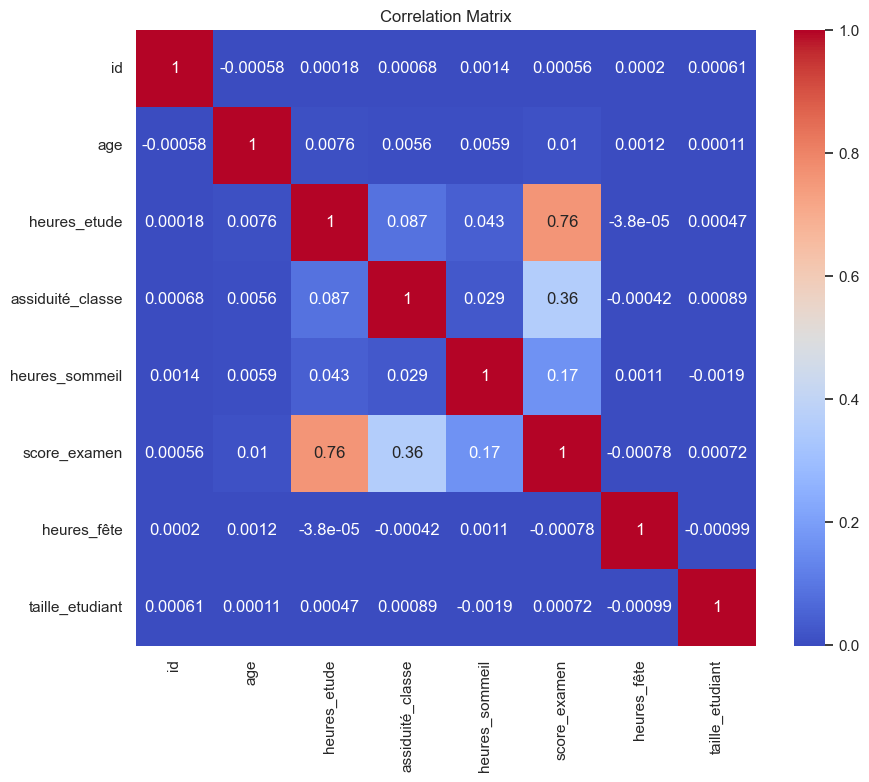

In [8]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#### Analysis

La matrice de corrélation met en évidence les relations entre les variables numériques et le score d’examen.

On observe une forte corrélation positive entre `heures_etude` et `score_examen` (≈ 0.76), ce qui indique que le temps consacré aux études est un facteur déterminant de la performance.

L’assiduité en classe présente également une corrélation positive modérée (≈ 0.36), ce qui suggère que la présence en cours contribue à améliorer les résultats.

Le nombre d’heures de sommeil montre une corrélation plus faible (≈ 0.17), indiquant un impact limité mais non négligeable.

En revanche, certaines variables comme l’âge, les heures de fête, la taille ou l’identifiant (`id`) n’ont pratiquement aucune corrélation avec le score d’examen. Ces variables pourraient être peu pertinentes pour la prédiction.

Enfin, la forte corrélation entre certaines variables et la cible confirme que le modèle de régression pourra exploiter ces relations linéaires.

### Relationship Between Key Features

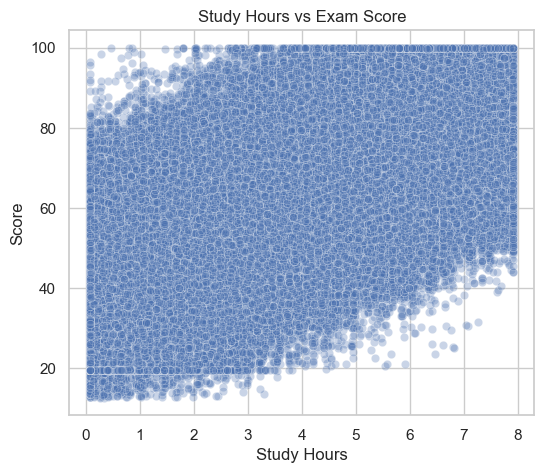

In [9]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["heures_etude"], y=df["score_examen"], alpha=0.3)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.show()

#### Analysis

Ce graphique met en évidence la relation entre le nombre d’heures d’étude et le score d’examen.

On observe une tendance positive : les étudiants qui consacrent davantage de temps à l’étude ont généralement de meilleurs résultats. Cela confirme la forte corrélation observée précédemment dans la matrice de corrélation.

Cependant, la dispersion des points montre que cette relation n’est pas parfaitement linéaire. Pour un même nombre d’heures d’étude, les scores peuvent varier de manière significative, ce qui indique que d’autres facteurs influencent également la performance.

On observe également un effet de plafond avec une concentration de valeurs proches de 100, ce qui suggère que certains étudiants atteignent le score maximal.

Cela montre que le temps d’étude est un facteur important mais non suffisant pour expliquer entièrement la performance académique.

### Attendance vs Exam Score

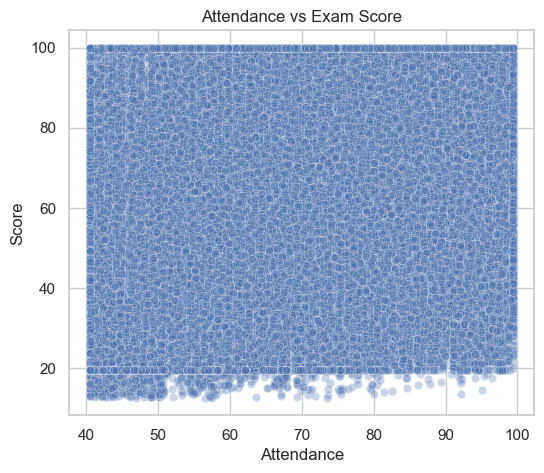

In [10]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["assiduité_classe"], y=df["score_examen"], alpha=0.3)
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Score")
plt.show()

#### Analysis

Ce graphique illustre la relation entre l’assiduité en classe et le score d’examen.

On observe une tendance globalement positive : les étudiants plus assidus ont tendance à obtenir de meilleurs résultats. Cela est cohérent avec la corrélation modérée observée précédemment.

Cependant, la dispersion importante des points indique que cette relation est moins forte que celle observée avec les heures d’étude. Pour un même niveau d’assiduité, les scores peuvent varier fortement.

De plus, certains étudiants ayant une forte assiduité obtiennent malgré tout des résultats faibles, ce qui suggère que la présence en classe ne garantit pas nécessairement une bonne compréhension.

Ainsi, l’assiduité apparaît comme un facteur important, mais insuffisant à elle seule pour expliquer la performance académique.

### Sleep Hours vs Exam Score

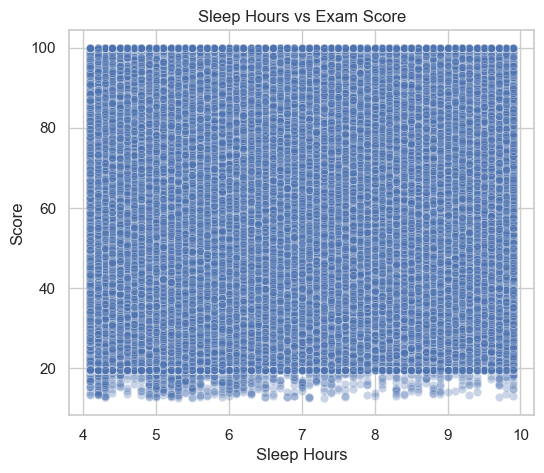

In [11]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["heures_sommeil"], y=df["score_examen"], alpha=0.3)
plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Score")
plt.show()

#### Analysis

Ce graphique montre la relation entre le nombre d’heures de sommeil et le score d’examen.

Contrairement aux variables précédentes, aucune tendance claire n’apparaît. Les points sont largement dispersés, ce qui indique une absence de relation forte entre ces deux variables.

Cela est cohérent avec la faible corrélation observée précédemment (≈ 0.17), suggérant que le sommeil a un impact limité sur les performances académiques dans ce dataset.

Bien que le sommeil puisse jouer un rôle indirect dans la concentration ou la fatigue, il ne semble pas être un facteur déterminant du score d’examen.

Ainsi, cette variable apparaît comme secondaire dans la prédiction des résultats.

### Categorical Features Analysis

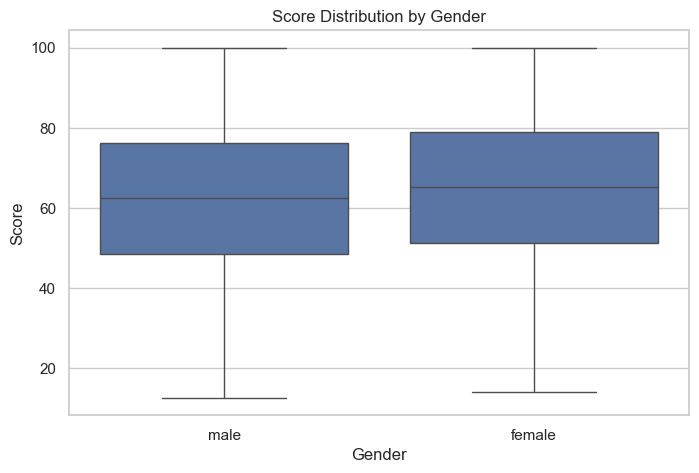

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["genre"], y=df["score_examen"])
plt.title("Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Score")
plt.show()

#### Analysis

Ce graphique compare la distribution des scores d’examen selon le genre.

On observe que la médiane des scores est légèrement plus élevée pour les femmes que pour les hommes. Cependant, les distributions se chevauchent largement, ce qui indique que la différence reste faible.

La dispersion des scores est similaire entre les deux groupes, avec des valeurs minimales et maximales comparables.

Ainsi, le genre ne semble pas être un facteur déterminant dans la performance académique dans ce dataset. Aucun biais majeur lié à cette variable n’est observé.

## Data Preprocessing

### Feature Types Identification

In [13]:
# variable cible
target = "score_examen"

# variables numériques
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# enlever target + id
numeric_features.remove(target)
if "id" in numeric_features:
    numeric_features.remove("id")

# variables catégorielles
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()

numeric_features, categorical_features

(['age',
  'heures_etude',
  'assiduité_classe',
  'heures_sommeil',
  'heures_fête',
  'taille_etudiant'],
 ['genre',
  'diplôme',
  'accès_internet',
  'qualité_sommeil',
  'méthode_etude',
  'évaluation_établissement',
  'difficulté_examen'])

Les variables ont été séparées selon leur type. Les variables numériques pourront être normalisées, tandis que les variables catégorielles devront être encodées avant l’entraînement des modèles.

La variable cible `score_examen` a été retirée des variables explicatives afin d’éviter une fuite de données. La variable `id` a également été exclue, car elle correspond uniquement à un identifiant technique et n’apporte pas d’information pertinente pour la prédiction.

### Missing Values Handling

In [14]:
df.isnull().sum()

id                              0
age                             0
genre                           0
diplôme                         0
heures_etude                18900
assiduité_classe                0
accès_internet              63000
heures_sommeil                  0
qualité_sommeil                 0
méthode_etude               44100
évaluation_établissement        0
difficulté_examen               0
score_examen                    0
heures_fête                     0
taille_etudiant                 0
dtype: int64

#### Analysis

L’analyse des valeurs manquantes montre que plusieurs variables contiennent des données absentes, notamment `heures_etude`, `accès_internet` et `méthode_etude`.

La variable `heures_etude`, qui est numérique et fortement corrélée au score d’examen, contient un nombre significatif de valeurs manquantes. Afin de conserver un maximum d’informations, une imputation par la moyenne sera utilisée.

Les variables catégorielles `accès_internet` et `méthode_etude` présentent également des valeurs manquantes importantes. Ces valeurs seront remplacées par la modalité la plus fréquente (most frequent), ce qui est une approche standard pour ce type de données.

Enfin, il est important de noter que certaines de ces variables peuvent être déclaratives, ce qui peut introduire des biais ou des incohérences dans les données. Cela sera pris en compte dans l’analyse critique du modèle.

### Preprocessing Pipeline

In [15]:
from sklearn.impute import SimpleImputer

# pipeline pour variables numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# pipeline pour variables catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combinaison des deux
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Ce pipeline sera appliqué uniquement sur les données d’entraînement afin d’éviter toute fuite de données (data leakage).

### train / validation / test

In [16]:
# séparation X / y
X = df.drop(columns=["score_examen"])
y = df["score_examen"]

# 1er split : train+val / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2e split : train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

X_train.shape, X_val.shape, X_test.shape

((378000, 14), (126000, 14), (126000, 14))

#### Analysis

Les données ont été divisées en trois ensembles :

- Un ensemble d’entraînement (60%) utilisé pour entraîner les modèles.
- Un ensemble de validation (20%) utilisé pour ajuster les hyperparamètres et comparer les modèles.
- Un ensemble de test (20%) utilisé pour évaluer les performances finales.

Cette séparation permet d’éviter le surapprentissage (overfitting) et d’obtenir une estimation plus fiable des performances du modèle sur des données non vues.

L’utilisation d’un ensemble de validation améliore la robustesse de l’évaluation par rapport à un simple découpage train/test.

### Baseline Model

In [17]:
from sklearn.dummy import DummyRegressor

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

# entraînement sur train
baseline_model.fit(X_train, y_train)

# prédictions sur validation
y_pred_baseline = baseline_model.predict(X_val)

# métriques
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
r2_baseline = r2_score(y_val, y_pred_baseline)

mae_baseline, rmse_baseline, r2_baseline

(15.653391880681154, np.float64(19.01761051649618), -9.689417836300507e-06)

#### Analysis

Le modèle baseline utilisé prédit simplement la moyenne des scores d’examen pour tous les étudiants.

Les résultats obtenus montrent une erreur relativement élevée (MAE ≈ 15.65, RMSE ≈ 19.02) et un coefficient de détermination proche de zéro (R² ≈ 0).

Cela signifie que le modèle n’explique aucune variance des données et ne capture aucune relation entre les variables.

Cette baseline constitue une référence minimale : les modèles plus complexes devront améliorer ces performances pour être considérés comme pertinents.

### Linear Regression

In [18]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# entraînement
linear_model.fit(X_train, y_train)

# prédictions sur validation
y_pred_linear = linear_model.predict(X_val)

# métriques
mae_linear = mean_absolute_error(y_val, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_val, y_pred_linear))
r2_linear = r2_score(y_val, y_pred_linear)

mae_linear, rmse_linear, r2_linear

(7.4209410154152895, np.float64(9.362706932727288), 0.757620899411472)

#### Analysis

La régression linéaire améliore fortement les performances par rapport à la baseline.

L’erreur moyenne absolue est divisée par deux (≈ 7.42 contre ≈ 15.65), et le coefficient de détermination atteint environ 0.76.

Cela signifie que le modèle explique environ 76% de la variance des données, ce qui indique une bonne capacité de prédiction.

Ces résultats suggèrent que les relations entre les variables explicatives et le score d’examen sont principalement linéaires.

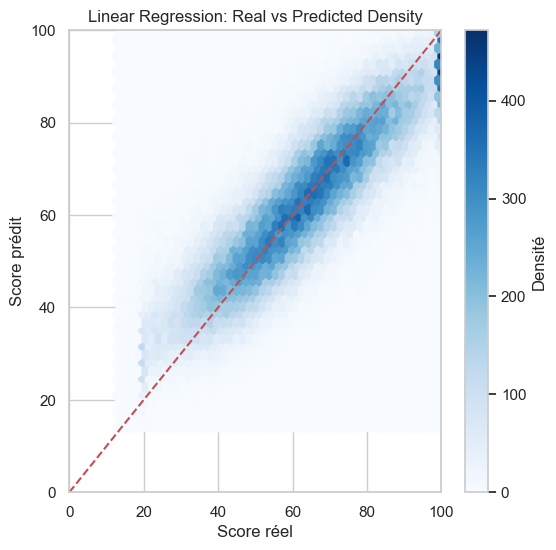

In [19]:
plt.figure(figsize=(6,6))
plt.hexbin(y_val, y_pred_linear, gridsize=50, cmap="Blues")

plt.plot([0, 100], [0, 100], "r--")
plt.colorbar(label="Densité")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Linear Regression: Real vs Predicted Density")

plt.show()

#### Graph Interpretation

Ce graphique de densité compare les scores réels aux scores prédits par la régression linéaire.

La zone la plus dense est proche de la diagonale, ce qui indique que le modèle prédit correctement une grande partie des observations.

Cependant, une dispersion reste visible autour de la diagonale, surtout pour certaines valeurs élevées. Cela montre que le modèle présente encore des erreurs et ne prédit pas parfaitement tous les cas.

Cette visualisation confirme donc les bonnes performances du modèle tout en mettant en évidence ses limites.

### Random Forest

In [20]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(7.5987310414285725, np.float64(9.592825943426018), 0.7455599691407031)

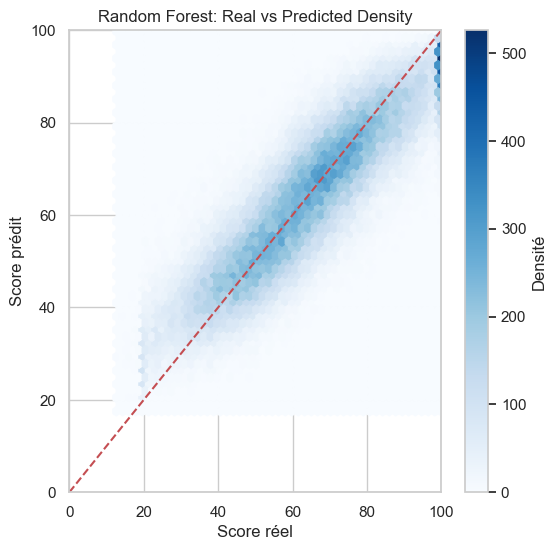

In [21]:
plt.figure(figsize=(6,6))
plt.hexbin(y_val, y_pred_rf, gridsize=50, cmap="Blues")

plt.plot([0, 100], [0, 100], "r--")
plt.colorbar(label="Densité")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Random Forest: Real vs Predicted Density")

plt.show()

#### Analysis

Le modèle Random Forest a été testé afin de capturer d’éventuelles relations non linéaires dans les données.

Cependant, les performances obtenues sont légèrement inférieures à celles de la régression linéaire (MAE ≈ 7.60 contre ≈ 7.42, R² ≈ 0.75 contre ≈ 0.76).

Le graphique de densité montre également une répartition des prédictions similaire à celle du modèle linéaire, sans amélioration notable.

Ces résultats suggèrent que les relations entre les variables explicatives et le score d’examen sont principalement linéaires.

Ainsi, l’utilisation d’un modèle plus complexe comme Random Forest n’apporte pas de gain significatif dans ce cas.

### Deep Learning Model - MLP

In [22]:
mlp_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(32,),   # plus simple
        activation="relu",
        solver="adam",
        max_iter=100,               # plus rapide
        early_stopping=True,        #  très important
        n_iter_no_change=10,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_val)

mae_mlp = mean_absolute_error(y_val, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_val, y_pred_mlp))
r2_mlp = r2_score(y_val, y_pred_mlp)

mae_mlp, rmse_mlp, r2_mlp

(7.410099277425467, np.float64(9.348449603275288), 0.758358516768815)

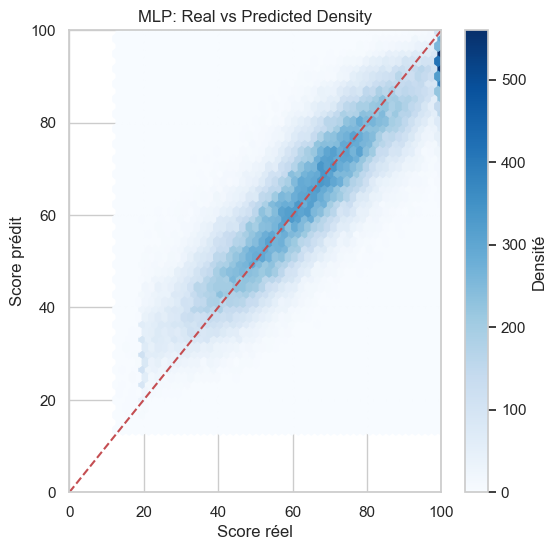

In [23]:
plt.figure(figsize=(6,6))
plt.hexbin(y_val, y_pred_mlp, gridsize=50, cmap="Blues")

plt.plot([0, 100], [0, 100], "r--")
plt.colorbar(label="Densité")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("MLP: Real vs Predicted Density")

plt.show()

#### Analysis

Le modèle de deep learning (MLP) a été testé afin de capturer des relations non linéaires dans les données.

Cependant, les performances obtenues sont très similaires à celles de la régression linéaire (MAE ≈ 7.41, R² ≈ 0.76).

Le graphique de densité confirme également une distribution des prédictions comparable aux modèles précédents.

De plus, le temps d’entraînement du MLP est significativement plus élevé, ce qui rend ce modèle moins efficace dans ce contexte.

Ces résultats confirment que les relations dans les données sont principalement linéaires et qu’un modèle simple comme la régression linéaire est suffisant.

Afin de limiter le temps d’entraînement, une architecture plus simple ainsi qu’un mécanisme d’arrêt anticipé (early stopping) ont été utilisés.

### Model Comparison

#### Construire le tableau

In [24]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest", "MLP"],
    "MAE": [mae_baseline, mae_linear, mae_rf, mae_mlp],
    "RMSE": [rmse_baseline, rmse_linear, rmse_rf, rmse_mlp],
    "R2": [r2_baseline, r2_linear, r2_rf, r2_mlp]
})

results

,Model,MAE,RMSE,R2
0,Baseline,15.653392,19.017611,-0.000010
1,Linear Regression,7.420941,9.362707,0.757621
2,Random Forest,7.598731,9.592826,0.745560
3,MLP,7.410099,9.348450,0.758359


#### Graphes propres (séparés)

##### MAE

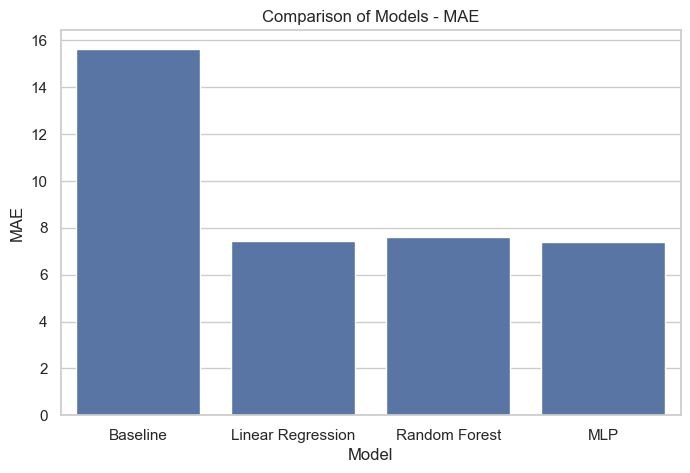

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="MAE")
plt.title("Comparison of Models - MAE")
plt.ylabel("MAE")
plt.show()

##### RMSE

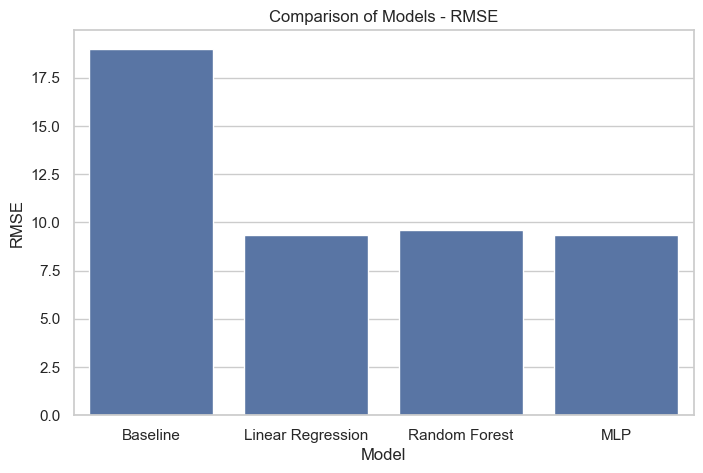

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="RMSE")
plt.title("Comparison of Models - RMSE")
plt.ylabel("RMSE")
plt.show()

##### R²

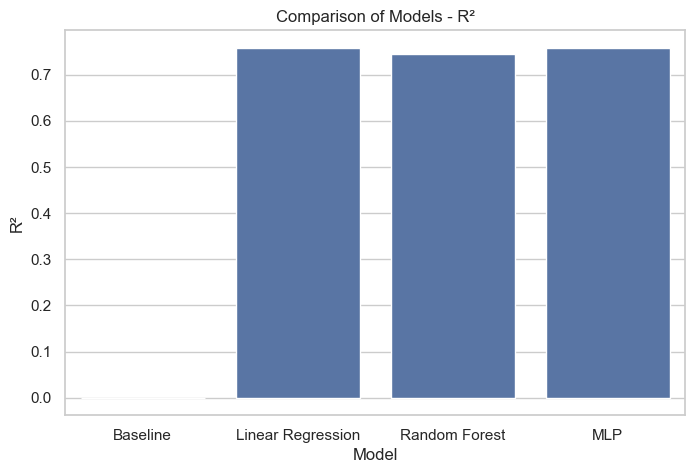

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="R2")
plt.title("Comparison of Models - R²")
plt.ylabel("R²")
plt.show()

#### Final Analysis

Les résultats montrent une amélioration significative des modèles par rapport à la baseline, ce qui confirme la pertinence des variables utilisées.

La régression linéaire obtient les meilleures performances globales, avec une erreur faible et un coefficient de détermination élevé.

Le modèle Random Forest, bien que plus complexe, n’apporte pas d’amélioration significative. Cela suggère que les relations entre les variables explicatives et la variable cible sont principalement linéaires.

Le modèle de deep learning (MLP) présente des performances similaires à la régression linéaire, mais avec un temps d’entraînement beaucoup plus élevé.

Ainsi, la régression linéaire apparaît comme le modèle le plus adapté à ce problème, offrant le meilleur compromis entre performance, simplicité et efficacité.

# Part B - Automatic Correction (OCR)

Dans cette partie, l’objectif est de construire un système de reconnaissance automatique de caractères manuscrits à partir du dataset fourni par le professeur.

## OCR Dataset Loading

In [40]:
import struct
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

class MyDataset(Dataset):
    def __init__(self, images_path, labels_path, mapping_path="image_data/mapping.txt"):
        # Load images
        with open(images_path, "rb") as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8)
            images = images.reshape(num, rows, cols)

        # Load labels
        with open(labels_path, "rb") as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)

        # Load mapping from label index -> ASCII code -> character
        self.mapping = {}
        try:
            with open(mapping_path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#"):
                        continue
                    idx_str, ascii_str = line.split(" ")
                    idx = int(idx_str)
                    ascii_val = int(ascii_str)
                    self.mapping[idx] = chr(ascii_val)
        except FileNotFoundError:
            raise FileNotFoundError(f"Mapping file not found: {mapping_path}")

        # Fix orientation (rotated)
        images = np.transpose(images, (0, 2, 1)).copy()

        # Convert to PyTorch tensors
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
        # Convert to character labels from mapping
        if not self.mapping:
            raise ValueError("Empty mapping, cannot map label indices to characters")
        self.char_labels = [self.mapping[int(l)] for l in labels]
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx].unsqueeze(0), self.char_labels[idx]

    def show_sample(self, idx=0, count=1):
        if count == 1:
            img, lbl = self[idx]
            img_np = img.squeeze(0).numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(img_np, cmap='gray')
            plt.title(f"Label: {lbl}")
            plt.axis('off')
            plt.show()
            return

        count = min(count, len(self)-idx)
        cols = min(5, count)
        rows = (count + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
        axes = np.array(axes).reshape(-1)

        for i in range(count):
            img, lbl = self[idx + i]
            img_np = img.squeeze(0).numpy()
            ax = axes[i]
            ax.imshow(img_np, cmap='gray')
            ax.set_title(f"{idx+i}:{lbl}", fontsize=10)
            ax.axis('off')

        for i in range(count, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()



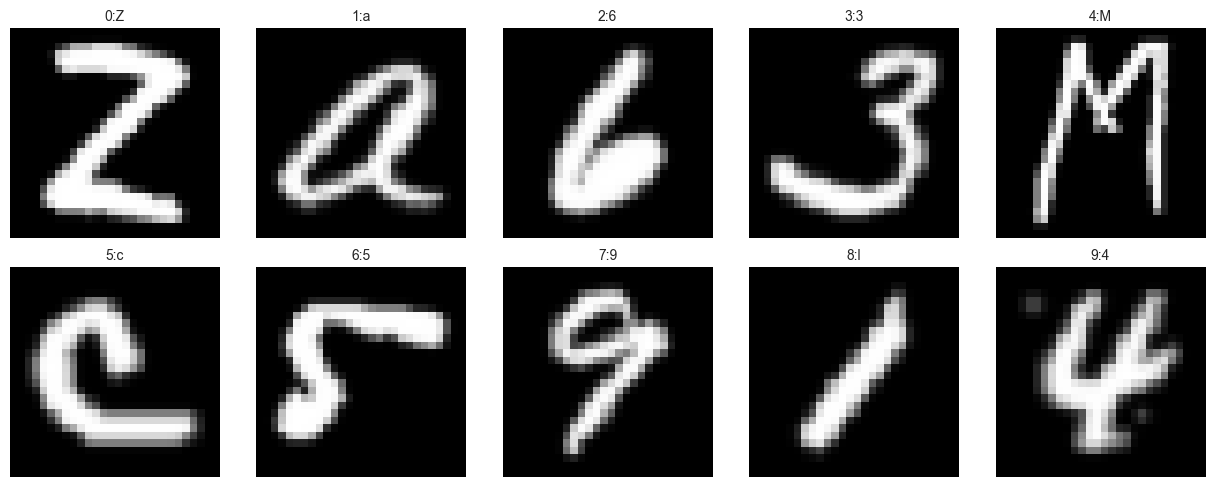

In [41]:
images_file = "../data/image_data/train-images-idx3-ubyte"
labels_file = "../data/image_data/train-labels-idx1-ubyte"
mapping_file = "../data/image_data/mapping.txt"

dataset = MyDataset(images_file, labels_file, mapping_file)

dataset.show_sample(idx=0, count=10)

#### Analysis

Le dataset fourni contient des images de caractères manuscrits (chiffres et lettres).

Chaque image est représentée sous forme de matrice de pixels en niveaux de gris.

Les labels associés sont convertis en caractères grâce à un fichier de mapping, permettant de passer d’un index numérique à un caractère ASCII.

On observe une grande variabilité dans la forme des caractères, ce qui rend la tâche de reconnaissance plus complexe et réaliste.

Ce dataset constitue une base pertinente pour développer un modèle de reconnaissance automatique de caractères (OCR).

## OCR Data Preprocessing

In [42]:
X = []
y = []

for img, lbl in dataset:
    X.append(img.numpy().flatten())  # image → vecteur
    y.append(lbl)

X = np.array(X)
y = np.array(y)

X.shape, y.shape

((697932, 784), (697932,))

#### Analysis

Après le preprocessing, le dataset OCR contient 697 932 images.

Chaque image de taille 28 × 28 pixels a été transformée en un vecteur de 784 valeurs numériques.

La variable `y` contient le caractère associé à chaque image. Il s’agit donc d’un problème de classification multiclasse, car le modèle doit prédire une classe parmi plusieurs caractères possibles.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((558345, 784), (139587, 784))

#### Analysis

Le dataset OCR a été divisé en deux ensembles :

- Un ensemble d’entraînement contenant 558 345 images.
- Un ensemble de test contenant 139 587 images.

L’ensemble d’entraînement sera utilisé pour apprendre au modèle à reconnaître les caractères manuscrits, tandis que l’ensemble de test permettra d’évaluer ses performances sur des images non vues.

Le paramètre `stratify=y` est utilisé afin de conserver une répartition équilibrée des différentes classes dans les deux ensembles. Cela est important dans un problème de classification multiclasse, car certaines classes peuvent être plus fréquentes que d’autres.

## OCR Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

ocr_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

ocr_model.fit(X_train, y_train)

y_pred = ocr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

accuracy